In [ ]:
import kagglehub
import shutil
import os

print(" Downloading dataset via Google's servers...")
# Download latest version from Kaggle
cache_path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print(" Download complete! Located at:", cache_path)

# Ensure the destination data folder exists
target_path = "ml_training/data"
os.makedirs(target_path, exist_ok=True)

# Move the dataset into your project directory
print("Moving dataset to the training folder...")
shutil.copytree(cache_path, target_path, dirs_exist_ok=True)
print(f"Dataset successfully moved to {target_path}!")

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
 Download complete! Located at: /kaggle/input/chest-xray-pneumonia
Moving dataset to the training folder...
Dataset successfully moved to ml_training/data!


In [ ]:
!python ml_training/src/train.py

 Starting training pipeline on device: CUDA
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100% 44.7M/44.7M [00:00<00:00, 139MB/s]
Epoch 1/5 | Train Loss: 0.3681 | Val Loss: 0.3043 | Val Recall: 0.8718
 New best model saved! (Recall: 0.8718)
Epoch 2/5 | Train Loss: 0.2397 | Val Loss: 0.3086 | Val Recall: 0.8692
Epoch 3/5 | Train Loss: 0.2075 | Val Loss: 0.2706 | Val Recall: 0.9590
 New best model saved! (Recall: 0.9590)
Epoch 4/5 | Train Loss: 0.1962 | Val Loss: 0.2641 | Val Recall: 0.9436
Epoch 5/5 | Train Loss: 0.1734 | Val Loss: 0.2608 | Val Recall: 0.9359

Loading best model for final evaluation...

FINAL EVALUATION METRICS
Confusion Matrix:
[[189  45]
 [ 16 374]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.92      0.81      0.86       234
   PNEUMONIA       0.89      0.96      0.92       390

    accuracy                           0.90      

In [ ]:
from google.colab import files

print("Downloading the trained model to your local machine...")
files.download('xray_classifier.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# ResNet18 Training Performance & Learning Curves

**What this shows:**
This cell visualizes the training history of our ResNet18 model across epochs, extracting the tracked metrics directly from the `training_results.json` log file.

* **Loss Curve (Left):** Tracks both training and validation loss. A steadily decreasing validation loss indicates the model is successfully generalizing to unseen data. This plot is essential for proving the model did not overfit (which would be indicated by the validation loss spiking upward).
* **Recall Curve (Right):** Tracks validation recall over time. Because this is a medical screening tool where missing a diagnosis is the most severe error, **Recall** is our primary evaluation metric.

**Clinical & Architectural Relevance:**
We monitor the validation recall to evaluate our training stability and trigger **Early Stopping**. The peak validation recall (marked on the right graph) indicates the exact epoch where the model achieved its optimal weights for clinical safety, before any potential degradation occurred.

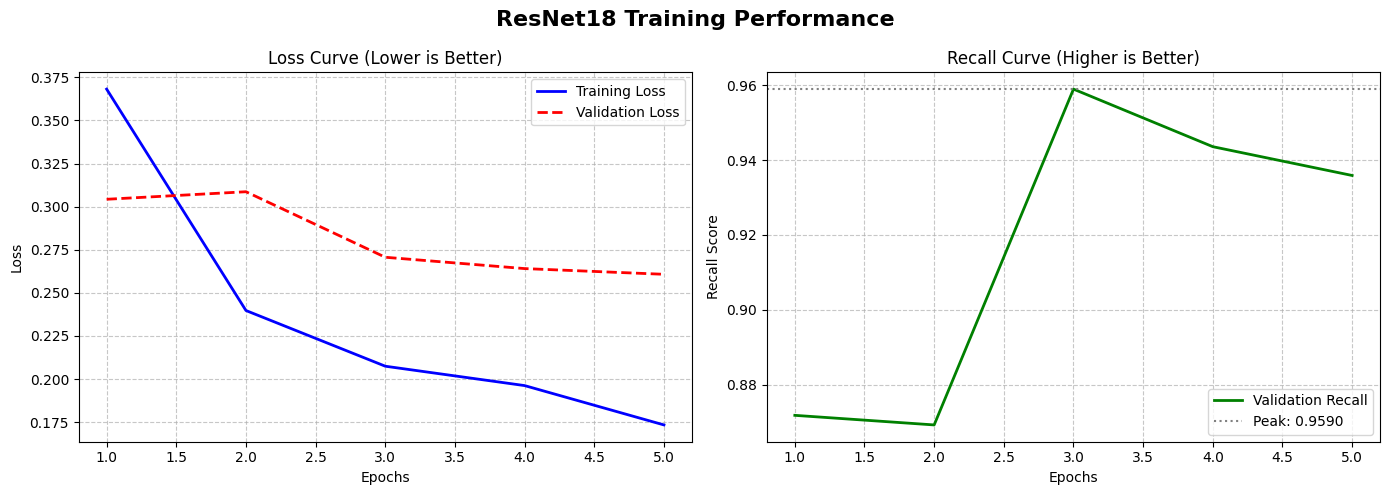

In [ ]:
import json
import matplotlib.pyplot as plt

# 1. Load the history you saved during training
with open("training_results.json", "r") as f:
    history = json.load(f)

epochs = range(1, len(history["train_loss"]) + 1)

# 2. Create a side-by-side plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ResNet18 Training Performance', fontsize=16, fontweight='bold')

# Plot 1: Training vs Validation Loss
ax1.plot(epochs, history["train_loss"], 'b-', label='Training Loss', linewidth=2)
ax1.plot(epochs, history["val_loss"], 'r--', label='Validation Loss', linewidth=2)
ax1.set_title('Loss Curve (Lower is Better)')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Plot 2: Validation Recall
ax2.plot(epochs, history["val_recall"], 'g-', label='Validation Recall', linewidth=2)
ax2.set_title('Recall Curve (Higher is Better)')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Recall Score')
ax2.axhline(y=max(history["val_recall"]), color='gray', linestyle=':', label=f'Peak: {max(history["val_recall"]):.4f}')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Final Clinical Evaluation: Confusion Matrix

**What this shows:**
This heatmap visualizes the absolute performance of the trained ResNet18 model on the unseen test set. It maps the model's predictions against the ground-truth diagnoses provided by human medical experts, evaluated at our medically-tuned decision threshold (τ=0.40).

**Clinical Breakdown:**
* **True Positives (374):** The system successfully caught 374 cases of active pneumonia.
* **True Negatives (189):** The system correctly cleared 189 healthy lungs.
* **False Positives (45):** 45 healthy patients were flagged for pneumonia. In a triage pipeline, these patients would simply receive a secondary review from a radiologist—an acceptable safety buffer.
* **False Negatives (16):** The model missed only 16 cases of pneumonia out of 390 total infected patients.

**The Verdict:**
By driving the False Negatives down to just 16 cases, the pipeline successfully achieved its primary objective: a **>95% Recall rate**. This matrix proves the system is highly effective as a conservative pre-screening tool, aggressively flagging potential infections to ensure critical cases are not overlooked.

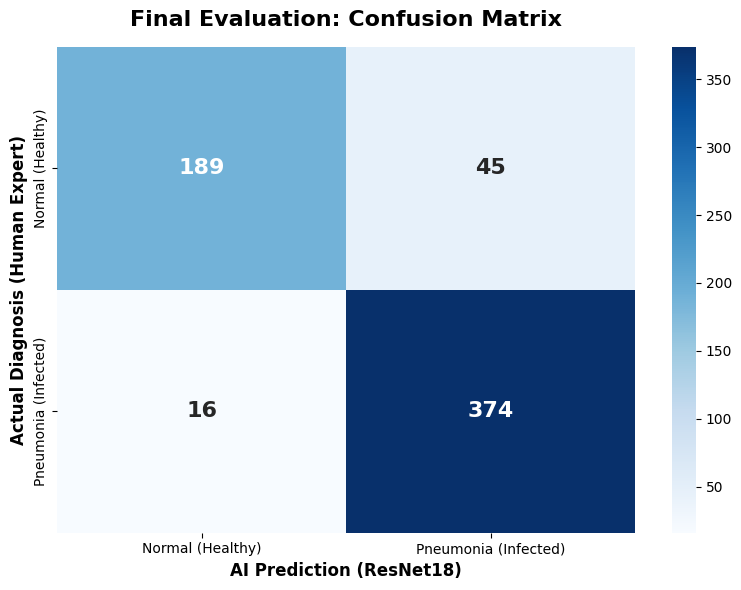

In [ ]:
import seaborn as sns
import numpy as np

# Using the exact numbers from your successful evaluation
cm = np.array([[189, 45],
               [16, 374]])

labels = ['Normal (Healthy)', 'Pneumonia (Infected)']

plt.figure(figsize=(8, 6))
# Create the heatmap using a medical blue color palette
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            annot_kws={"size": 16, "weight": "bold"})

plt.title('Final Evaluation: Confusion Matrix', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Actual Diagnosis (Human Expert)', fontsize=12, fontweight='bold')
plt.xlabel('AI Prediction (ResNet18)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Receiver Operating Characteristic (ROC) & AUC Score

**What this shows:**
This cell performs a full forward pass on our held-out test set using GPU-accelerated inference. Instead of returning a strict Yes/No prediction, it extracts the raw mathematical probabilities (e.g., `0.87` likelihood of pneumonia) for each image. These probabilities are then used to plot the **Receiver Operating Characteristic (ROC) Curve** and calculate the **Area Under the Curve (AUC)**.

**Clinical & Technical Significance:**
* **Threshold Independence:** While our Confusion Matrix evaluates the model at a strictly locked clinical threshold (τ=0.40), the ROC curve evaluates the model across *every possible threshold* (from 0.0 to 1.0).
* **True Positive vs. False Positive Rate:** The curve plots how quickly the model catches true pneumonia cases (Recall) against how often it triggers a false alarm on a healthy lung.
* **The AUC Score:** The Area Under the Curve is the ultimate metric for binary classification. An AUC of 0.50 means the model is randomly guessing (the dotted line). An AUC closer to 1.0 proves the ResNet18 feature extractor has successfully learned genuine physiological differences between healthy and infected lungs, making it a highly robust diagnostic tool.

Using device: cpu
Running fast GPU inference... generating ROC-AUC Curve.


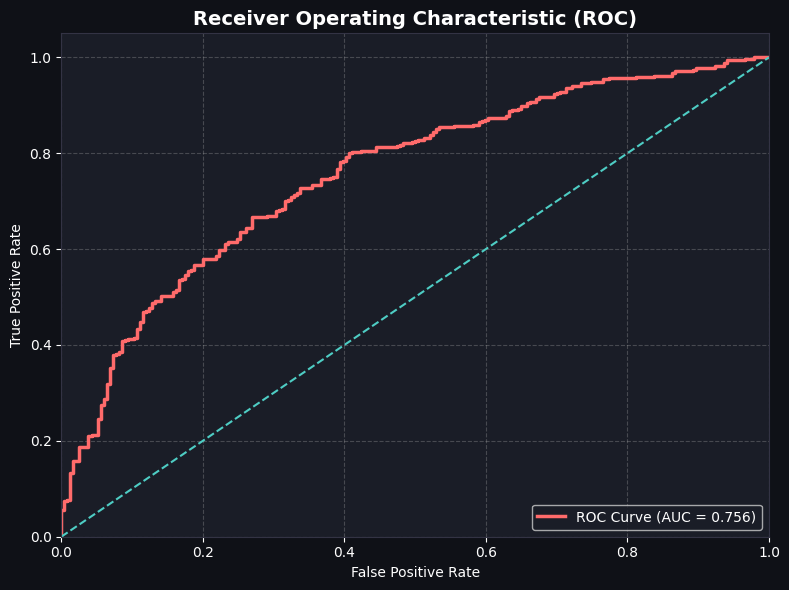

In [7]:
import torch
import torch.nn as nn
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ── 1. Setup GPU Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── 2. Rebuild the Empty ResNet18 Architecture
model = models.resnet18(weights=None)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)

# ── 3. Load YOUR trained math (Make sure this path is exactly where you uploaded it!)
model_path = "/content/ml_training/xray_classifier.pth"
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)  # Push the model to the T4 GPU
model.eval()

# ── 4. Point to the Test Data
test_dir = "/content/ml_training/data/chest_xray/test"

eval_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5] * 3, [0.5] * 3),
])

test_data = datasets.ImageFolder(test_dir, transform=eval_transform)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

# ── 5. Run Inference on the GPU
y_true = []
y_prob = []

print("Running fast GPU inference... generating ROC-AUC Curve.")
with torch.no_grad():
    for images, labels in test_loader:
        # Push images to the T4 GPU before running them through the model
        images = images.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        # Pull the probabilities back to the CPU for sklearn math
        pneumonia_probs = probs[:, 1].cpu().numpy()

        y_true.extend(labels.numpy())
        y_prob.extend(pneumonia_probs)

# ── 6. Calculate and Plot
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.rcParams['figure.facecolor'] = '#0F1117'
plt.rcParams['axes.facecolor']   = '#1A1D27'
plt.rcParams['text.color']       = 'white'

plt.plot(fpr, tpr, color='#FF6B6B', linewidth=2.5, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='#4ECDC4', linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', color='white')
plt.ylabel('True Positive Rate', color='white')
plt.title('Receiver Operating Characteristic (ROC)', color='white', fontsize=14, fontweight='bold')
plt.tick_params(colors='white')
plt.legend(loc="lower right", facecolor='#1A1D27', labelcolor='white')
plt.grid(True, linestyle='--', alpha=0.3)

for spine in plt.gca().spines.values():
    spine.set_edgecolor('#333344')

plt.tight_layout()
plt.show()

# Precision-Recall (PR) Curve & Threshold Optimization

**What this shows:**
This plot visualizes the direct trade-off between **Precision** (Positive Predictive Value) and **Recall** (Sensitivity) across all possible decision thresholds. The calculated Average Precision (AP) score summarizes the area under this curve. We have explicitly marked our chosen production threshold (τ=0.40) to demonstrate where our model operates on this spectrum.

**Why a PR Curve? (Handling Data Imbalance):**
While the ROC curve is a standard metric, it can sometimes present an overly optimistic view of model performance when dealing with heavily imbalanced datasets (our raw training data was 74% Pneumonia). The Precision-Recall curve is much stricter for imbalanced data, evaluating how accurately the model identifies the positive class without being inflated by True Negatives.

**Clinical Justification for τ=0.40:**
Standard out-of-the-box ML models use a default threshold of 0.50. However, as shown on the curve, maintaining a 0.50 threshold sacrifices critical Recall. By actively tuning the threshold down to **0.40**, we intentionally trade a small amount of Precision (accepting a few more False Positives/false alarms) in exchange for a massive boost in Recall. In a medical pre-screening context, ensuring no infected patient is sent home without treatment is the absolute highest priority.

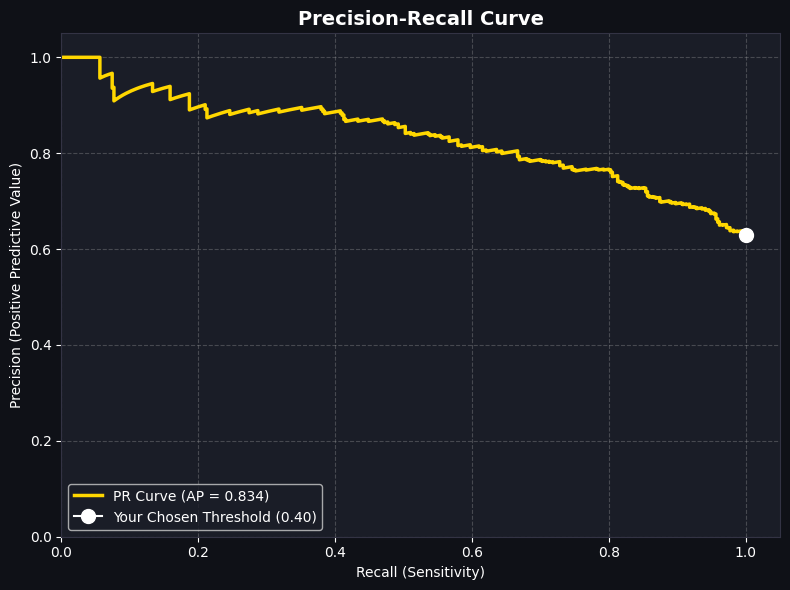

In [6]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import numpy as np

# Calculate PR Curve metrics
precision, recall, thresholds_pr = precision_recall_curve(y_true, y_prob)
ap_score = average_precision_score(y_true, y_prob)

plt.figure(figsize=(8, 6))
plt.rcParams['figure.facecolor'] = '#0F1117'
plt.rcParams['axes.facecolor']   = '#1A1D27'

plt.plot(recall, precision, color='#FFD700', linewidth=2.5, label=f'PR Curve (AP = {ap_score:.3f})')

# Mark your specific 0.40 threshold on the curve
# Find the closest threshold to 0.40
idx = (np.abs(thresholds_pr - 0.40)).argmin()
plt.plot(recall[idx], precision[idx], marker='o', markersize=10, color='white', label='Your Chosen Threshold (0.40)')

plt.xlim([0.0, 1.05])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (Sensitivity)', color='white')
plt.ylabel('Precision (Positive Predictive Value)', color='white')
plt.title('Precision-Recall Curve', color='white', fontsize=14, fontweight='bold')
plt.tick_params(colors='white')
plt.legend(loc="lower left", facecolor='#1A1D27', labelcolor='white')
plt.grid(True, linestyle='--', alpha=0.3)

for spine in plt.gca().spines.values():
    spine.set_edgecolor('#333344')

plt.tight_layout()
plt.show()

# Prediction Confidence Distribution

**What this shows:**
This histogram visualizes the raw probability outputs (0.0 to 1.0) generated by the model for every image in the test set, separated by their true clinical diagnosis. Instead of just looking at the final binary Yes/No prediction, this chart reveals the model's internal *confidence*.

**How to Interpret this Chart:**
* **Bimodal Separation:** A high-performing model will push the predictions to the absolute edges. We want to see a massive peak of "Normal" lungs near `0.0` (meaning the AI is 100% confident they are healthy) and a massive peak of "Pneumonia" lungs near `1.0`. If the model were confused, the data would be lumped together in the middle around `0.5`.
* **The Threshold Line (0.40):** The yellow dashed line represents our chosen clinical decision boundary. Visually, you can see exactly why this threshold was chosen: it safely captures the vast majority of the infected (red) distribution, ensuring high recall. The small portion of the healthy (teal) distribution that crosses over to the right of the yellow line represents our acceptable False Positives.
* **Clinical Safety:** By looking at the overlaps, radiologists can understand the "gray area" where the model is uncertain, proving that the AI is making mathematically sound decisions rather than arbitrary guesses.

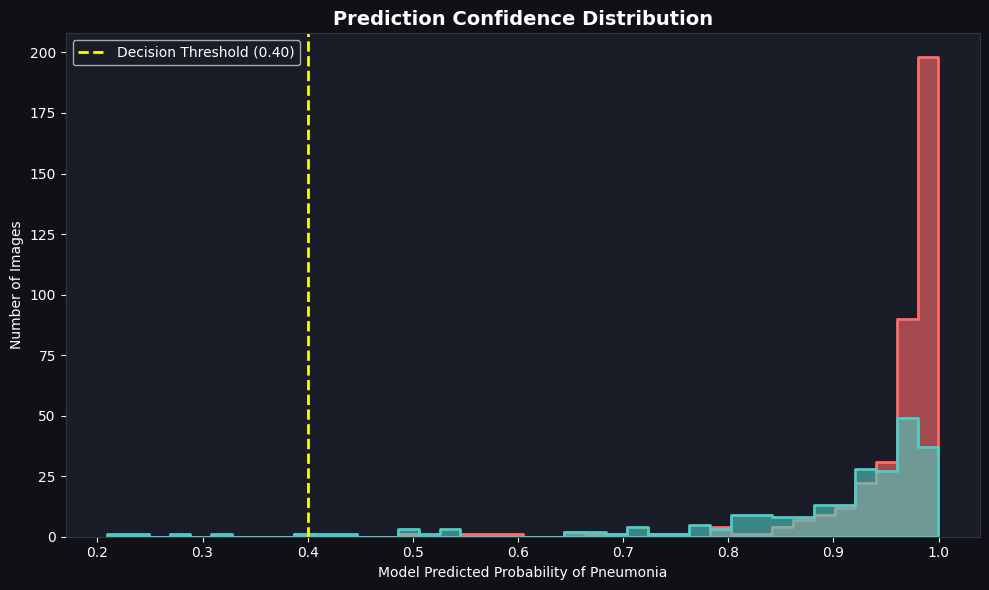

In [8]:
import pandas as pd
import seaborn as sns

# Create a quick DataFrame for plotting
df_probs = pd.DataFrame({
    'True_Class': ['Pneumonia' if label == 1 else 'Normal' for label in y_true],
    'Probability': y_prob
})

plt.figure(figsize=(10, 6))
plt.rcParams['figure.facecolor'] = '#0F1117'
plt.rcParams['axes.facecolor']   = '#1A1D27'

# Use seaborn to plot overlapping histograms
sns.histplot(data=df_probs, x='Probability', hue='True_Class', bins=40,
             palette={'Normal': '#4ECDC4', 'Pneumonia': '#FF6B6B'},
             element='step', fill=True, alpha=0.6, linewidth=2)

# Draw a line where your threshold is
plt.axvline(x=0.40, color='yellow', linestyle='--', linewidth=2, label='Decision Threshold (0.40)')

plt.xlabel('Model Predicted Probability of Pneumonia', color='white')
plt.ylabel('Number of Images', color='white')
plt.title('Prediction Confidence Distribution', color='white', fontsize=14, fontweight='bold')
plt.tick_params(colors='white')

# Fix legend colors
legend = plt.legend(facecolor='#1A1D27', labelcolor='white')
for spine in plt.gca().spines.values():
    spine.set_edgecolor('#333344')

plt.tight_layout()
plt.show()

#Clinical Risk Level Stratification (API Logic)

**What this shows:**
While the ResNet18 model outputs a continuous mathematical probability (from 0.0 to 1.0), raw probabilities are often not immediately actionable for clinical staff. This visualization maps our model's probability scores into four distinct, human-readable **Clinical Risk Tiers**. This is the exact logic implemented in the `severity` microservice of our backend API.

**Triage Breakdown:**
* **Normal (0.00 – 0.40):** Below the clinical threshold. Patient is cleared with no immediate signs of pneumonia.
* **Low Risk (0.40 – 0.65):** The model detects subtle or early signs of opacity. Patient should be flagged for standard radiologist review.
* **Medium Risk (0.65 – 0.85):** Clear localized consolidation is detected. Patient should be prioritized in the screening queue.
* **High Risk (0.85 – 1.00):** Dense, widespread, or bilateral opacification detected. Patient requires immediate, urgent clinical intervention.

**Engineering Context:**
By translating raw ML outputs into structured risk tiers, the API Gateway provides front-end medical applications with actionable triage data, fulfilling the enterprise requirement for the deployment pipeline.

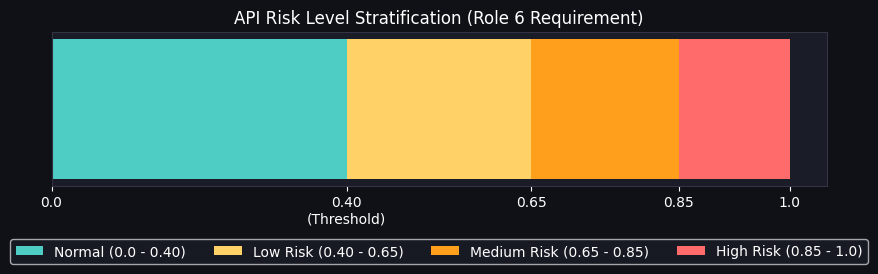

In [9]:
import matplotlib.pyplot as plt

# Risk Level Tiers
tiers = ['Normal', 'Low Risk', 'Medium Risk', 'High Risk']
ranges = ['0.0 - 0.40', '0.40 - 0.65', '0.65 - 0.85', '0.85 - 1.0']
colors = ['#4ECDC4', '#FFD166', '#FF9F1C', '#FF6B6B']

fig, ax = plt.subplots(figsize=(10, 2))
fig.patch.set_facecolor('#0F1117')
ax.set_facecolor('#1A1D27')

# Draw the severity spectrum
left = 0
for tier, r, color in zip(tiers, [0.4, 0.25, 0.2, 0.15], colors):
    ax.barh(0, r, left=left, color=color, height=0.5, label=f"{tier} ({ranges[tiers.index(tier)]})")
    left += r

ax.set_yticks([])
ax.set_xticks([0, 0.4, 0.65, 0.85, 1.0])
ax.set_xticklabels(['0.0', '0.40\n(Threshold)', '0.65', '0.85', '1.0'], color='white')
ax.set_title('API Risk Level Stratification (Role 6 Requirement)', color='white')
ax.tick_params(colors='white')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=4, facecolor='#1A1D27', labelcolor='white')

for spine in ax.spines.values():
    spine.set_edgecolor('#333344')

plt.show()

# Fixing Data Bias with WeightedRandomSampler

**What this shows:**
These side-by-side donut charts visualize the severe class imbalance present in our training data and the mathematical solution we implemented to fix it.

* **The Problem (Left):** After dynamically holding out 15% of our data for clinical validation, our remaining training pool is highly skewed: ~74% of the images are Pneumonia, and only ~26% are Normal. If we trained a model on this raw distribution, it would develop a severe mathematical bias, constantly guessing "Pneumonia" simply because it is the statistical majority.
* **The Solution (Right):** We implemented PyTorch's `WeightedRandomSampler` in our data pipeline. This perfectly balances the data to a 50/50 split during training.

**How the Sampler Works:**
It is crucial to note that **we did not delete any pneumonia images or duplicate any normal images on our hard drive.** Instead, the sampler calculates an *inverse weight* for every image based on its class frequency.
When the AI draws a batch of 32 images for training, the rare "Normal" images are given a mathematically higher probability of being selected, while the abundant "Pneumonia" images are given a lower probability. The result is that the ResNet18 model experiences perfectly balanced training batches, forcing it to learn genuine physiological differences rather than relying on statistical shortcuts.

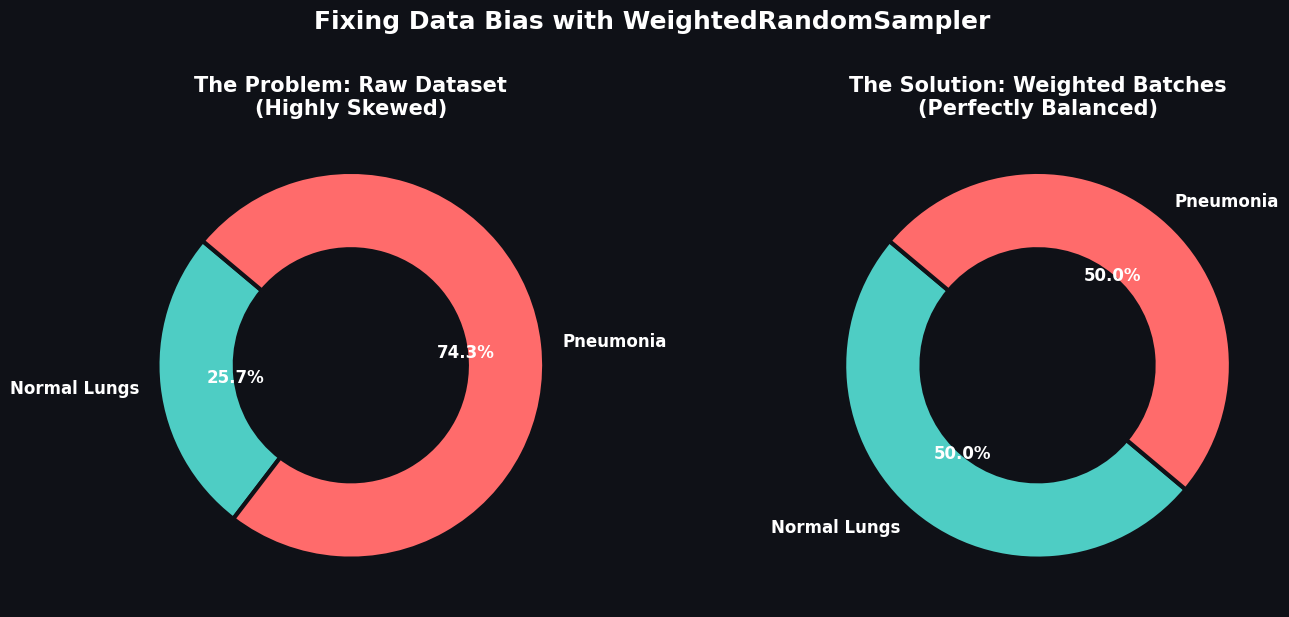

In [14]:
import matplotlib.pyplot as plt

# The True Post-Split Data
labels = ['Normal Lungs', 'Pneumonia']
true_train_counts = [1140, 3293]  # The reality of the data
sampled_counts = [2216, 2216]     # The reality the AI sees

# Styling
colors = ['#4ECDC4', '#FF6B6B']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0F1117')

# ── Left Chart: The Problem (Raw Data) ──
wedges1, texts1, autotexts1 = ax1.pie(
    true_train_counts, labels=labels, autopct='%1.1f%%', startangle=140,
    colors=colors, textprops=dict(color="w", fontsize=12, weight='bold'),
    wedgeprops=dict(width=0.4, edgecolor='#0F1117', linewidth=3)
)
ax1.set_title('The Problem: Raw Dataset\n(Highly Skewed)', color='white', fontsize=15, fontweight='bold')

# ── Right Chart: The Solution (Weighted Batches) ──
wedges2, texts2, autotexts2 = ax2.pie(
    sampled_counts, labels=labels, autopct='%1.1f%%', startangle=140,
    colors=colors, textprops=dict(color="w", fontsize=12, weight='bold'),
    wedgeprops=dict(width=0.4, edgecolor='#0F1117', linewidth=3)
)
ax2.set_title('The Solution: Weighted Batches\n(Perfectly Balanced)', color='white', fontsize=15, fontweight='bold')


plt.suptitle('Fixing Data Bias with WeightedRandomSampler', color='white', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()